In [1]:
import pickle
import os
from collections import defaultdict
def load_graphs(path):
    with open(path, "rb") as f:
        data = pickle.load(f)
    return data

def save_results(results, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "wb") as f:
        pickle.dump(results, f)

def to_dict(obj):
    if isinstance(obj, defaultdict):
        return {k: to_dict(v) for k, v in obj.items()}
    return obj

In [2]:
for p in range(20):
    if not os.path.exists(f"fig_data/fig13/fig13_p{p:02d}.pkl"):
        raise FileNotFoundError(f"Data file for p={p} not found. Please run the simulation to generate the data.")

Fig 13a


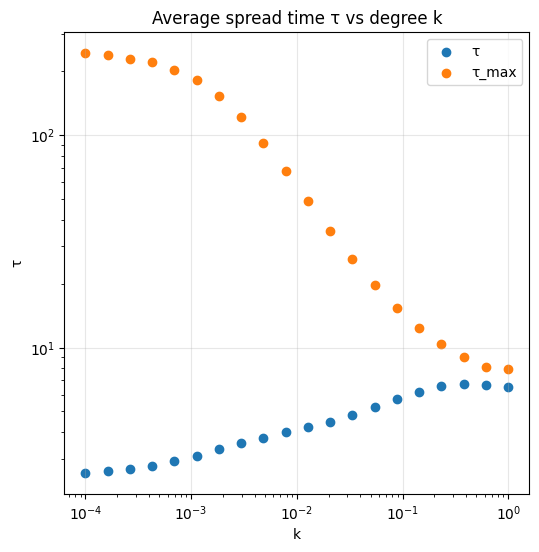

In [9]:
import matplotlib.pyplot as plt
import numpy as np

#Spread time
plt.figure(figsize=(6, 6))
sw_data_by_p = defaultdict(list)
for p in range(20):
    sw_data_by_k = load_graphs(f"fig_data/fig13/fig13_p{p:02d}.pkl")
    for k in sw_data_by_k:
        sw_data_by_p[p].extend(sw_data_by_k[k]["spread_time"])
    del sw_data_by_k
sw_plot_data_by_p = {p: sum(times) / len(times) for p, times in sw_data_by_p.items()}
p_range = np.logspace(-4, 0, 20).tolist()
plt.scatter(p_range, [sw_plot_data_by_p[p_range.index(p)] for p in p_range], label="τ")
del sw_data_by_p, sw_plot_data_by_p

#Max time
sw_data_by_p = defaultdict(list)
for p in range(20):
    sw_data_by_k = load_graphs(f"fig_data/fig13/fig13_p{p:02d}.pkl")
    for k in sw_data_by_k:
        sw_data_by_p[p].extend(sw_data_by_k[k]["time"])
    del sw_data_by_k
sw_plot_data_by_p = {p: sum(times) / len(times) for p, times in sw_data_by_p.items()}
p_range = np.logspace(-4, 0, 20).tolist()
plt.scatter(p_range, [sw_plot_data_by_p[p_range.index(p)] for p in p_range], label="τ_max")
del sw_data_by_p, sw_plot_data_by_p

print("Fig 13a")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("k")
plt.ylabel("τ")
plt.title("Average spread time τ vs degree k")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Fig 13b


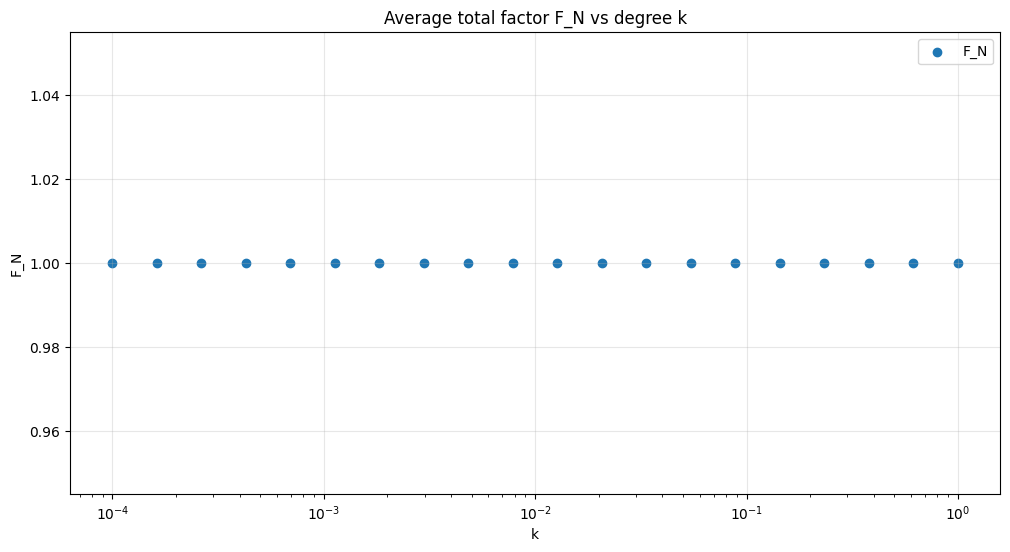

In [12]:
#Total factor
plt.figure(figsize=(12, 6))
sw_data_by_p = defaultdict(list)
for p in range(20):
    sw_data_by_k = load_graphs(f"fig_data/fig13/fig13_p{p:02d}.pkl")
    for k in sw_data_by_k:
        sw_data_by_p[p].extend(sw_data_by_k[k]["total_factor"])
    del sw_data_by_k
sw_plot_data_by_p = {p: sum(factor) / len(factor) for p, factor in sw_data_by_p.items()}
p_range = np.logspace(-4, 0, 20).tolist()
plt.scatter(p_range, [sw_plot_data_by_p[p_range.index(p)] for p in p_range], label="F_N")
del sw_data_by_p, sw_plot_data_by_p

print("Fig 13b")
plt.xscale("log")
plt.xlabel("k")
plt.ylabel("F_N")
plt.title("Average total factor F_N vs degree k")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()